# Customer Loyalty Scorer (NPS): four competitors, "starting a company" track

BYU MAcc strategy course. This notebook turns **real, public, star-rated reviews** into a review-derived Net Promoter Score
for four named competitors, shows how sensitive each score is to the bucket boundary, states sample size and bias per
company, and asks the starting-a-company question: *is there an incumbent serving many customers unremarkably?*

**The Strategic Project has been narrowed since the last two deliverables.** `pipeline.ipynb` and `five_forces.ipynb` used the
general framing "fractional CFO services for US small/mid-sized businesses (NAICS 541611)". The team has since sharpened it to
**bookkeeping, tax and loan-readiness for independent estheticians and spa/suite owners**: people who are excellent at
their craft but often mishandle 1099 vs. W-2 classification, mix personal and business spending, and over-minimize taxable
profit until it hurts their loan eligibility. Only the four competitors are scored; the student's own company is pre-launch.

| Stage | What happens here |
|---|---|
| 0 | Setup: paths, load the review cache |
| 1 | Where the reviews came from, per company, and why that source |
| 2 | Bucket each review and score; 4-star sensitivity |
| 3 | Sample size, uncertainty and selection bias per company |
| 4 | Three real excerpts (promoter, passive, detractor) |
| 5 | Chart: NPS by company |
| 6 | Track analysis: loyalty vs. review volume, and the wedge |
| 7 | Write `nps_data.json` (the PDF is built from it) |
| A | Appendix: full source of the review collector |

**Who did what.** Reviews were retrieved by `collect_reviews.py` (Playwright, a real headless browser) and cached in `cache/`.
Every number below is computed by code from that cache. The prose judgments (bucket rationale, bias sentences, wedge reading)
were drafted by Claude Code, an LLM agent, during the build session, and sit in this notebook where they can be checked
against the numbers printed next to them.

## Stage 0: Setup

In [1]:
import json, math, re, datetime as dt
from pathlib import Path
from collections import Counter
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

HERE = Path.cwd()
CACHE = HERE / "cache"
ORDER = ["kopsa_otte", "xendoo", "elite_business_solutions", "jasmine_thomas"]
RECOLLECT = False      # True re-runs the browser collector (about 10 minutes); False uses the committed cache
if RECOLLECT:
    import collect_reviews; collect_reviews.main()

data = {s: json.loads((CACHE / f"{s}.json").read_text()) for s in ORDER}
for s in ORDER:
    d = data[s]
    print(f"{d['company']:<32} cache/{s}.json  itemized reviews: {len(d['reviews']):>3}  retrieved: {d['retrieved']}")

Kopsa Otte CPAs and Advisors     cache/kopsa_otte.json  itemized reviews:   2  retrieved: 2026-10-08
Xendoo                           cache/xendoo.json  itemized reviews: 177  retrieved: 2026-10-08
Elite Business Solutions         cache/elite_business_solutions.json  itemized reviews:   4  retrieved: 2026-10-08
Jasmine Thomas & Associates      cache/jasmine_thomas.json  itemized reviews:   0  retrieved: 2026-10-08


## Stage 1: Where the reviews came from, and why

**Rule applied to all four companies (same order for each, so the scores are comparable):**
1. **Trustpilot first.** It is server-rendered and needs no login. Used only if a company has at least ~15 reviews there.
2. **Google Maps fallback.** The public Places API returns at most 5 "most relevant" reviews per listing, which is useless
   for NPS, so the collector loads the listing in a real headless browser, scrolls the Reviews list until nothing new loads
   (2-3 s between scrolls, 3-5 s between page loads), and reads each review's star rating off the page. It also reads
   Google's **star histogram** (Google's own count of every rating on the listing) as an independent cross-check.
3. **Yelp** was checked where the company itself linked a Yelp page. Yelp answers automated browsers with HTTP 403; that is
   logged, not worked around.

What happened: **Trustpilot had zero usable reviews for all four companies** (two have pages with 0 reviews, two have no page),
so **all four fall back to Google Maps**. That keeps the comparison on one source after all. The table is built from the
attempt log the collector wrote into each cache file.

In [2]:
def attempt_summary(d):
    out = []
    for a in d["attempts"]:
        if a["source"] == "Trustpilot":
            out.append("Trustpilot: " + ("no page (404)" if a.get("exists") is False else
                       f"page exists, {a.get('review_count')} reviews" + (" (claimed)" if a.get("claimed") else "")))
        elif a["source"] == "Yelp":
            out.append(f"Yelp: HTTP {a.get('http_status')} (blocks automated browsers)")
        elif a["source"] == "Google Maps":
            l = a["listing"]
            out.append(f"Google Maps: '{l['name']}', {l['address']}" + (" [PERMANENTLY CLOSED]" if l.get("permanently_closed") else "")
                       + f", {l.get('listed_review_count')} reviews listed")
        elif a["source"] == "Google Maps search":
            names = [r.get("name") for r in a["results"]]
            out.append(f"Google Maps search -> {names[:3]}")
    return out

sources = {}
for s in ORDER:
    d = data[s]
    print(f"\n{d['company']}  (website: {d['website']}; retrieved {d['retrieved']})")
    for line in attempt_summary(d):
        print("   -", line)
    print("   SOURCE USED:", d.get("source_used") or "none: no reviewable public presence found")
    print("   Identity check:", d["identity_note"])
    sources[s] = {"source_used": d.get("source_used"), "source_url": d.get("source_url"),
                  "attempts": attempt_summary(d), "identity_note": d["identity_note"], "retrieved": d["retrieved"]}


Kopsa Otte CPAs and Advisors  (website: kopsaotte.com; retrieved 2026-10-08)
   - Trustpilot: no page (404)
   - Google Maps: 'Kopsa Otte Associates LLC', 306 E 7th St, York, NE 68467, 2 reviews listed
   SOURCE USED: Google Maps
   Identity check: Google listing 'Kopsa Otte Associates LLC' at 306 E 7th St, York, NE 68467, phone (402) 362-6636, website kopsaotte.com; the same street address and phone are printed on kopsaotte.com.

Xendoo  (website: xendoo.com; retrieved 2026-10-08)
   - Trustpilot: page exists, 0 reviews (claimed)
   - Google Maps: 'Xendoo Online Accounting, Bookkeeping & Tax', 6700 N Andrews Ave #300, Fort Lauderdale, FL 33309, 177 reviews listed
   SOURCE USED: Google Maps
   Identity check: Google listing 'Xendoo Online Accounting, Bookkeeping & Tax' at 6700 N Andrews Ave #300, Fort Lauderdale, FL (company HQ), website xendoo.com. Reviews are firm-wide, not limited to the Beauty & Wellness vertical; Google does not separate them.

Elite Business Solutions  (website

**Source reasoning, per company**

* **Kopsa Otte CPAs and Advisors**: no Trustpilot page. Google listing "Kopsa Otte Associates LLC" carries the same street address
  and phone as kopsaotte.com, so it is the right business. Used: Google Maps.
* **Xendoo**: Trustpilot page exists with 0 reviews. Google listing at the Fort Lauderdale HQ links to xendoo.com. Used: Google Maps.
  Caveat: the listing covers the whole firm; Google does not separate Beauty & Wellness clients from the rest.
* **Elite Business Solutions**: claimed Trustpilot page with 0 reviews. Its domain is now **for sale**. The archived site's own
  "review us on Google" button points to a listing now marked **permanently closed**; that listing was used. A same-name firm
  in Omaha was checked and rejected (different website).
* **Jasmine Thomas & Associates**: no Trustpilot page, no Google listing under the firm's name, and the domain is a
  **parked GoDaddy page**. Nothing scorable exists, so no NPS is computed (shown as n = 0, never as 0).

Two of the three beauty-specialist firms appear to have left the market, or at least their web presence. That is part of the
finding, not noise; Stage 6 comes back to it.

## Stage 2: Bucket and score

**Boundary used (primary): 5 stars = Promoter, 4 stars = Passive, 1-3 stars = Detractor.**

Why 4 stars is *passive*, not promoter: NPS asks "how likely are you to recommend us, 0-10" and counts only 9-10 as promoters.
A 5-point star scale has to be squeezed onto that. On Google, 5 stars is the default "happy" rating, so a reviewer who
holds back the fifth star is signalling a reservation; that is the satisfied-but-not-enthusiastic customer NPS calls passive.
Mapping 1-3 stars to detractor matches NPS treating 0-6 (most of the scale) as detractor: on review sites a 3-star is
already a complaint. This is a judgment call, so the alternative (4 stars counted as promoters) is computed for every
company right next to it.

**Count source.** Each company's score is computed from the itemized reviews in its cache (one review = one respondent).
Google's histogram is then used as a check: the itemized star counts must equal the histogram exactly, or the notebook stops.

In [3]:
def bucket(stars, four_is_promoter=False):
    if stars == 5 or (stars == 4 and four_is_promoter): return "promoter"
    if stars == 4: return "passive"
    if 1 <= stars <= 3: return "detractor"
    raise ValueError(stars)

def score(star_list, four_is_promoter=False):
    n = len(star_list)
    if n == 0:
        return {"n": 0, "promoters": 0, "passives": 0, "detractors": 0, "pct_promoters": None, "pct_detractors": None, "nps": None}
    c = Counter(bucket(x, four_is_promoter) for x in star_list)
    pp, pd = 100 * c["promoter"] / n, 100 * c["detractor"] / n
    return {"n": n, "promoters": c["promoter"], "passives": c["passive"], "detractors": c["detractor"],
            "pct_promoters": round(pp, 1), "pct_detractors": round(pd, 1), "nps": int(round(pp - pd))}

results = {}
for s in ORDER:
    d = data[s]
    stars = [r["stars"] for r in d["reviews"]]
    itemized = {str(k): stars.count(k) for k in range(5, 0, -1)}
    hist = d.get("star_histogram")
    if hist is not None:
        assert itemized == hist, f"{s}: itemized {itemized} != Google histogram {hist}"
    results[s] = {"company": d["company"], "stars": itemized, "histogram": hist,
                  "primary": score(stars), "alt_4star_promoter": score(stars, four_is_promoter=True)}

print(f"{'Company':<30}{'n':>5}{'5*':>5}{'4*':>4}{'3*':>4}{'2*':>4}{'1*':>4} {'%Prom':>7}{'%Det':>7}  {'NPS':>5}   check vs Google histogram")
for s in ORDER:
    r = results[s]; p = r["primary"]; st = r["stars"]
    nps = "n/a" if p["nps"] is None else f"{p['nps']:+d}"
    chk = "matches exactly" if r["histogram"] else "no listing"
    pr = "-" if p["pct_promoters"] is None else f"{p['pct_promoters']:.1f}"
    de = "-" if p["pct_detractors"] is None else f"{p['pct_detractors']:.1f}"
    print(f"{r['company']:<30}{p['n']:>5}{st['5']:>5}{st['4']:>4}{st['3']:>4}{st['2']:>4}{st['1']:>4} {pr:>7}{de:>7}  {nps:>5}   {chk}")

Company                           n   5*  4*  3*  2*  1*   %Prom   %Det    NPS   check vs Google histogram
Kopsa Otte CPAs and Advisors      2    2   0   0   0   0   100.0    0.0   +100   matches exactly
Xendoo                          177  164   1   1   2   9    92.7    6.8    +86   matches exactly
Elite Business Solutions          4    4   0   0   0   0   100.0    0.0   +100   matches exactly
Jasmine Thomas & Associates       0    0   0   0   0   0       -      -    n/a   no listing


### 4-star sensitivity: primary boundary vs. "4 stars count as promoters"

In [4]:
print(f"{'Company':<30}{'n':>5}{'4-star reviews':>16}{'NPS (4*=passive)':>19}{'NPS (4*=promoter)':>20}{'change':>8}")
for s in ORDER:
    r = results[s]; a, b = r["primary"], r["alt_4star_promoter"]
    f = lambda v: "n/a" if v is None else f"{v:+d}"
    ch = "n/a" if a["nps"] is None else f"{b['nps'] - a['nps']:+d}"
    print(f"{r['company']:<30}{a['n']:>5}{r['stars']['4']:>16}{f(a['nps']):>19}{f(b['nps']):>20}{ch:>8}")
four_total = sum(results[s]["stars"]["4"] for s in ORDER); n_total = sum(results[s]["primary"]["n"] for s in ORDER)
print(f"\nAcross all {n_total} reviews only {four_total} is/are 4-star ({100*four_total/n_total:.1f}%). "
      "The boundary choice barely matters here because almost nobody leaves a 4-star review for these firms.")

Company                           n  4-star reviews   NPS (4*=passive)   NPS (4*=promoter)  change
Kopsa Otte CPAs and Advisors      2               0               +100                +100      +0
Xendoo                          177               1                +86                 +86      +0
Elite Business Solutions          4               0               +100                +100      +0
Jasmine Thomas & Associates       0               0                n/a                 n/a     n/a

Across all 183 reviews only 1 is/are 4-star (0.5%). The boundary choice barely matters here because almost nobody leaves a 4-star review for these firms.


The sensitivity result is itself evidence of the **bimodal bias** discussed in Stage 3: the passive bucket is almost empty.
On a real NPS survey, passives (7-8) are usually a large share of customers. Here they nearly vanish, because people who
feel "fine" about their bookkeeper rarely write a review at all.

## Stage 3: Sample size, uncertainty, and selection bias

**Uncertainty.** A score from 2 reviews cannot be read with the same confidence as one from 177. To make that visible, each
NPS gets a 95% interval from a simple Bayesian model: the true promoter/passive/detractor shares get a flat Dirichlet(1,1,1)
prior, updated with the observed counts, and NPS is computed for 100,000 draws (fixed seed). The interval reported is the
*highest-density* 95% interval (the shortest range holding 95% of the plausible values), so it always contains the most
likely value. With 2 or 4 reviews it spans a large part of the -100 to +100 scale, which is the honest answer.
For the all-5-star firms the interval tops out just under +100: the observed score is +100, but the model is estimating the
*true* score across all their customers, and with only 2 or 4 reviews it is very likely that some customers are not promoters.

**Bimodal-review bias (applies to every company).** People mostly leave reviews when they are delighted or furious and
rarely when things were just "fine". A review-derived NPS therefore probably **overstates how polarized real customers are**
compared with a proper random-sample NPS survey: real passives are under-counted, and both promoters and detractors are
over-represented relative to their true share. On top of that, firms can *ask* happy clients for reviews (Xendoo replies
to most of its reviews and many name a specific staff member, which is consistent with prompted reviews), which pushes
scores up.

In [5]:
rng = np.random.default_rng(20261008)
def interval(p):
    if p["n"] == 0: return None
    draws = rng.dirichlet([p["promoters"] + 1, p["passives"] + 1, p["detractors"] + 1], size=100_000)
    nps = np.sort(100 * (draws[:, 0] - draws[:, 2]))
    k = int(0.95 * len(nps))                       # highest-density interval: the shortest window holding 95% of draws
    i = int(np.argmin(nps[k:] - nps[:len(nps) - k]))
    return [int(round(nps[i])), int(round(nps[i + k]))]

def confidence_label(n):
    if n == 0: return "none: no reviews exist to score"
    if n < 10: return "very low: anecdote, not a score"
    if n < 30: return "low: wide error bars"
    if n < 100: return "moderate"
    return "reasonable for a review-based score (still not a survey)"

BIAS = {
 "kopsa_otte": "Two Google reviewers out of a 30-year, 25-person salon-and-spa CPA practice: clients of a niche B2B accountant almost never "
               "review it, so the two who did were people moved to praise a named staff member, not a cross-section of the client base.",
 "xendoo": "Firm-wide reviews (not just Beauty & Wellness clients) with the owner replying to nearly every one and a large cluster dated "
           "within the same year, which is consistent with Xendoo asking satisfied clients to review; unhappy clients surface mainly as "
           "1-star complaints, so the 177 over-represent both the prompted-happy and the furious.",
 "elite_business_solutions": "Four 5-star reviews, the newest about two years old, on a listing Google now marks permanently closed: a "
           "survivorship snapshot of the clients who chose to praise the firm before it shut, which says nothing about why it closed.",
 "jasmine_thomas": "No reviews exist on any source checked, so there is no sample to be biased; the absence itself is the data point "
           "(a one-person beauty-industry practice whose website is now a parked domain).",
}
dates = {s: Counter(r.get("date_relative") for r in data[s]["reviews"]) for s in ORDER}
for s in ORDER:
    r = results[s]; p = r["primary"]
    r["ci95"] = interval(p)
    r["alt_ci95"] = interval(r["alt_4star_promoter"])
    r["confidence"] = confidence_label(p["n"])
    r["selection_bias"] = BIAS[s]
    with_text = sum(1 for x in data[s]["reviews"] if x["text"])
    replied = sum(1 for x in data[s]["reviews"] if x.get("owner_replied"))
    r["with_text"], r["owner_replied"] = with_text, replied
    nps = "n/a" if p["nps"] is None else f"{p['nps']:+d}"
    ci = "n/a" if r["ci95"] is None else f"[{r['ci95'][0]:+d}, {r['ci95'][1]:+d}]"
    print(f"{r['company']}\n   n = {p['n']}  NPS = {nps}  95% interval {ci}  confidence: {r['confidence']}")
    if p["n"]:
        top_date, top_n = dates[s].most_common(1)[0]
        print(f"   {with_text} of {p['n']} reviews have text; owner replied to {replied}; most common date label: '{top_date}' ({top_n} reviews).")
    print(f"   Selection bias: {r['selection_bias']}\n")

Kopsa Otte CPAs and Advisors
   n = 2  NPS = +100  95% interval [-22, +96]  confidence: very low: anecdote, not a score
   2 of 2 reviews have text; owner replied to 0; most common date label: 'a year ago' (1 reviews).
   Selection bias: Two Google reviewers out of a 30-year, 25-person salon-and-spa CPA practice: clients of a niche B2B accountant almost never review it, so the two who did were people moved to praise a named staff member, not a cross-section of the client base.

Xendoo
   n = 177  NPS = +86  95% interval [+77, +92]  confidence: reasonable for a review-based score (still not a survey)
   163 of 177 reviews have text; owner replied to 160; most common date label: 'a year ago' (76 reviews).
   Selection bias: Firm-wide reviews (not just Beauty & Wellness clients) with the owner replying to nearly every one and a large cluster dated within the same year, which is consistent with Xendoo asking satisfied clients to review; unhappy clients surface mainly as 1-star complaints, 

**Reading the sample sizes plainly.** Only Xendoo clears the 50-review target (177). Kopsa Otte (2) and Elite (4) are far
below it, and Jasmine Thomas & Associates has none. That shortfall is a real finding for this track: the beauty-specialist
bookkeepers have almost no public reputation signal at all. Kopsa Otte's and Elite's "+100" are **not** evidence that they are
better liked than Xendoo; their intervals overlap almost the whole scale.

## Stage 4: Three real excerpts that show the bucketing at work

Rule: one 5-star (promoter), one 4-star (passive) and one 1-3-star (detractor) review, each with text, quoted from the cache
with its company, source and Google review id so it can be traced. The code asserts every quote is a verbatim slice of the
cached review text.

In [6]:
def find(rid):
    for s in ORDER:
        for r in data[s]["reviews"]:
            if r["review_id"] == rid:
                return s, r
    raise KeyError(rid)

pool = {b: [(s, r) for s in ORDER for r in data[s]["reviews"] if r["text"] and bucket(r["stars"]) == b]
        for b in ["promoter", "passive", "detractor"]}
print("Reviews with text available per bucket:", {b: len(v) for b, v in pool.items()})
for b in ["passive", "detractor"]:
    for s, r in pool[b]:
        print(f"\n[{b}] {data[s]['company']} | {r['stars']} stars | {r['date_relative']} | id {r['review_id']}\n  {r['text'][:400]}")

Reviews with text available per bucket: {'promoter': 155, 'passive': 1, 'detractor': 11}

[passive] Xendoo | 4 stars | a year ago | id Ci9DQUlRQUNvZENodHljRjlvT2pKR01WRlJPUzFWY0hwUGNWUkdNSG8xVmpaaVZGRRAB
  Your experience with Xendoo will completely depend on which accountant you are assigned. Rae Robinson has been an absolute pleasure to work with - she's on top of everything and makes my life much easier!

[detractor] Xendoo | 1 stars | 9 months ago | id Ci9DQUlRQUNvZENodHljRjlvT2tzd05UZDBja1k1YVZGdk9GZ3hkbk16ZDNoNldHYxAB
  I hired this firm to prepare and file my 2023 taxes. I later started receiving multiple notices from the IRS and the State of North Carolina, including one stating that my 2023 return was not filed.
When I first contacted the firm about IRS notices related to Form 8962, I was told that the issue was on my end and was sent a revised page with instructions to mail it to the IRS myself. When I asked 

[detractor] Xendoo | 3 stars | a year ago | id ChdDSUhNMG9nS0VJQ0F

In [7]:
# Chosen after reading every passive and detractor candidate above and the promoters in the cache.
# Each pick is the clearest illustration of WHY a review lands in its bucket.
PROMOTER_ID = data["kopsa_otte"]["reviews"][[r["text"].startswith("We work with Theresa") for r in data["kopsa_otte"]["reviews"]].index(True)]["review_id"]
PICKS = {
    "promoter":  {"id": PROMOTER_ID, "max_words": 45},
    "passive":   {"id": "Ci9DQUlRQUNvZENodHljRjlvT2pKR01WRlJPUzFWY0hwUGNWUkdNSG8xVmpaaVZGRRAB", "max_words": 13},
    "detractor": {"id": "Ci9DQUlRQUNvZENodHljRjlvT2tzd05UZDBja1k1YVZGdk9GZ3hkbk16ZDNoNldHYxAB", "max_words": 37},
}
WHY = {
    "promoter":  "Five stars and unreserved enthusiasm (the client looks forward to tax meetings): the kind of customer who recommends unprompted. It also comes from the salon-and-spa specialist, the closest match to our niche.",
    "passive":   "Four stars with a built-in reservation: the reviewer is happy with one accountant but warns the firm itself is a lottery. Satisfied, but not someone who would recommend the firm without caveats. That is a passive. It is the only 4-star review among all 183.",
    "detractor": "One star: the firm was paid to file a return that was never filed, and follow-up stopped. A customer who actively warns others is a detractor, and the failure (tax compliance and follow-through) is exactly the pain point our esthetician clients fear.",
}
def short(text, max_words):
    words = text.split()
    return " ".join(words[:max_words]) + (" ..." if len(words) > max_words else "")

excerpts = []
for b, pick in PICKS.items():
    s, r = find(pick["id"])
    assert bucket(r["stars"]) == b, (b, r["stars"])
    q = short(r["text"], pick["max_words"])
    assert re.sub(r"\s+", " ", q.rstrip(" .")).replace(" ...", "") in re.sub(r"\s+", " ", r["text"]), "quote is not verbatim"
    excerpts.append({"bucket": b, "company": data[s]["company"], "stars": r["stars"], "date": r["date_relative"],
                     "source": r["source"], "source_url": r["source_url"], "review_id": r["review_id"], "quote": q, "why": WHY[b]})
    print(f"{b.upper()} ({r['stars']} stars) - {data[s]['company']}, {r['source']}, {r['date_relative']}, review id {r['review_id']}")
    print(f'  "{q}"')
    print(f"  Why this bucket: {WHY[b]}\n")

PROMOTER (5 stars) - Kopsa Otte CPAs and Advisors, Google Maps, a year ago, review id ChZDSUhNMG9nS0VJQ0FnTURnNzREeWVBEAE
  "We work with Theresa and I look forward to our tax meetings because she is so knowledgeable and enjoyable to work with!!"
  Why this bucket: Five stars and unreserved enthusiasm (the client looks forward to tax meetings): the kind of customer who recommends unprompted. It also comes from the salon-and-spa specialist, the closest match to our niche.

PASSIVE (4 stars) - Xendoo, Google Maps, a year ago, review id Ci9DQUlRQUNvZENodHljRjlvT2pKR01WRlJPUzFWY0hwUGNWUkdNSG8xVmpaaVZGRRAB
  "Your experience with Xendoo will completely depend on which accountant you are assigned. ..."
  Why this bucket: Four stars with a built-in reservation: the reviewer is happy with one accountant but warns the firm itself is a lottery. Satisfied, but not someone who would recommend the firm without caveats. That is a passive. It is the only 4-star review among all 183.

DETRACTOR (1 sta

**A boundary edge case worth seeing.** Xendoo's single 3-star review (printed above) praises the accountant and says "I highly
recommend Xendoo", yet under the rule it counts as a detractor, because the rule reads stars, not words. Re-bucketing it as
a passive would move Xendoo's NPS by less than one point, so it does not change any conclusion. It is a reminder that a star
rating is a noisy proxy for the 0-10 recommend question.

## Stage 5: Chart, NPS by company (best to worst, 95% intervals)

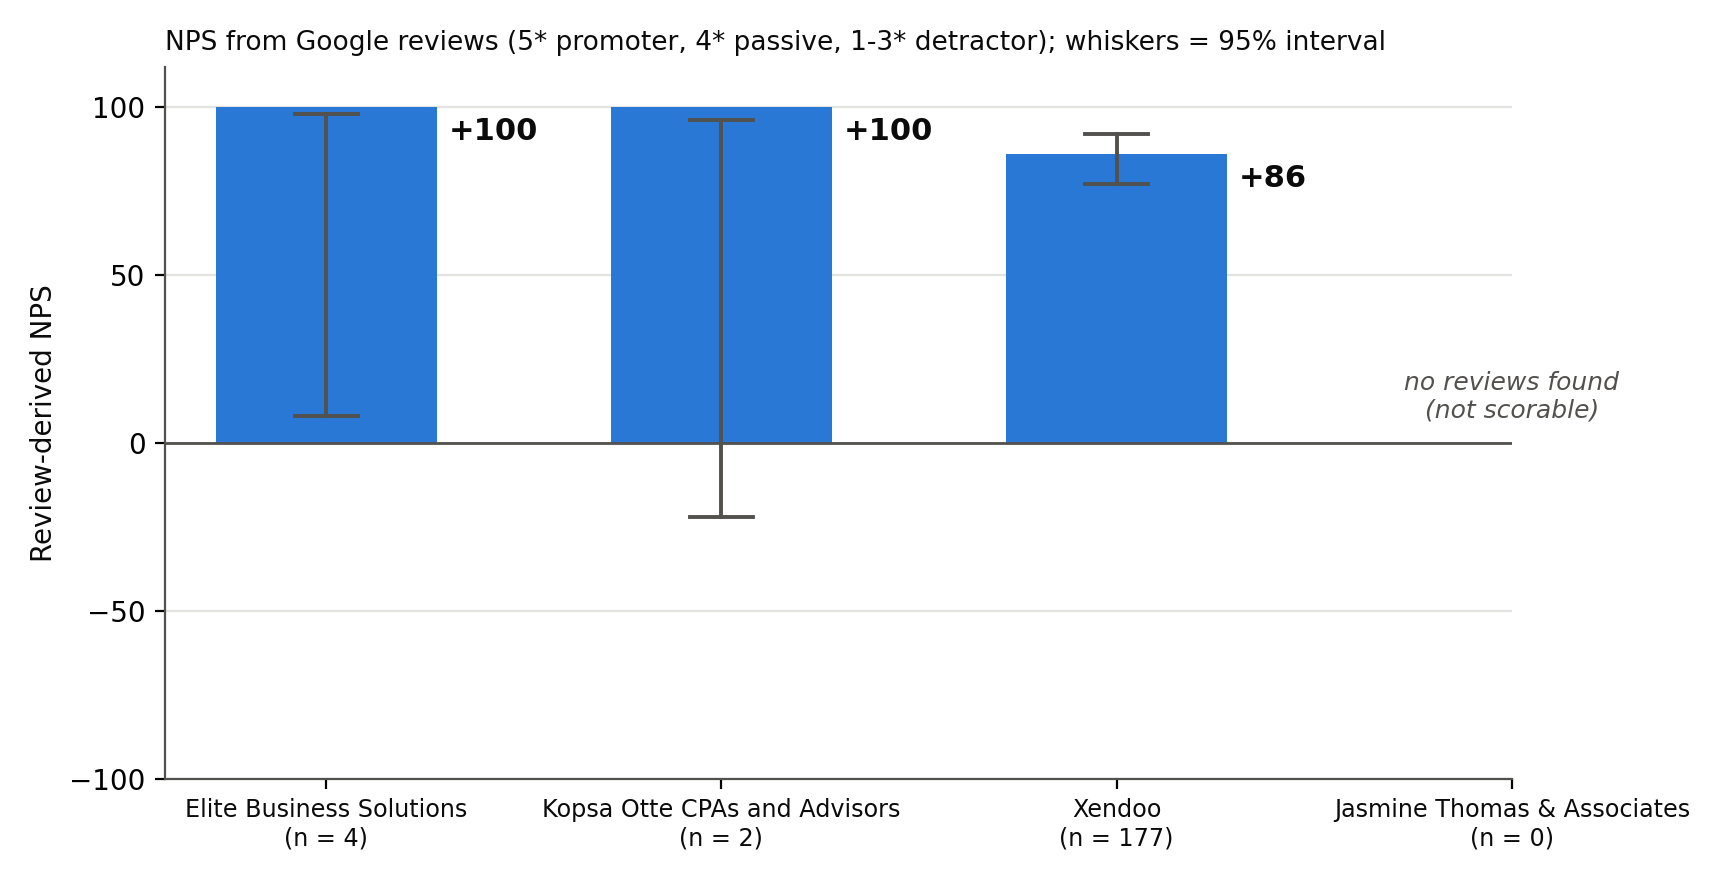

In [8]:
INK, MUTED, GRID, BAR = "#0b0b0b", "#52514e", "#e4e3df", "#2a78d6"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10, "axes.edgecolor": MUTED})
scored = sorted([s for s in ORDER if results[s]["primary"]["nps"] is not None],
                key=lambda s: (results[s]["primary"]["nps"], results[s]["primary"]["n"]), reverse=True)
unscored = [s for s in ORDER if results[s]["primary"]["nps"] is None]
labels = [f"{results[s]['company']}\n(n = {results[s]['primary']['n']})" for s in scored + unscored]
fig, ax = plt.subplots(figsize=(8.6, 4.4), dpi=200)
xs = np.arange(len(labels))
for i, s in enumerate(scored):
    p = results[s]["primary"]; lo, hi = results[s]["ci95"]
    ax.bar(i, p["nps"], width=0.56, color=BAR, zorder=2)
    ax.plot([i, i], [lo, hi], color=MUTED, lw=1.4, zorder=3)
    for y in (lo, hi): ax.plot([i - 0.08, i + 0.08], [y, y], color=MUTED, lw=1.4, zorder=3)
    ax.text(i + 0.31, p["nps"] - 3, f"{p['nps']:+d}", ha="left", va="top", color=INK, fontsize=11, fontweight="bold")
for j, s in enumerate(unscored):
    i = len(scored) + j
    ax.text(i, 6, "no reviews found\n(not scorable)", ha="center", va="bottom", color=MUTED, fontsize=9, style="italic")
ax.axhline(0, color=MUTED, lw=1)
ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=8.6, color=INK)
ax.set_ylim(-100, 112); ax.set_yticks(range(-100, 101, 50))
ax.set_ylabel("Review-derived NPS", color=INK)
ax.grid(axis="y", color=GRID, lw=0.8, zorder=0)
for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
ax.set_title("NPS from Google reviews (5* promoter, 4* passive, 1-3* detractor); whiskers = 95% interval",
             fontsize=9.5, color=INK, loc="left")
fig.tight_layout(); fig.savefig(HERE / "nps_chart.png"); plt.close(fig)
display(Image(filename=str(HERE / "nps_chart.png"), width=760))

## Stage 6: Track analysis (starting a company): loyalty vs. review volume

The starting-a-company question: is there a competitor with **high review volume and mediocre or low NPS** (lots of customers
served unremarkably), which would mark room to enter? Volume is plotted on a log scale because the counts run from 0 to 177.

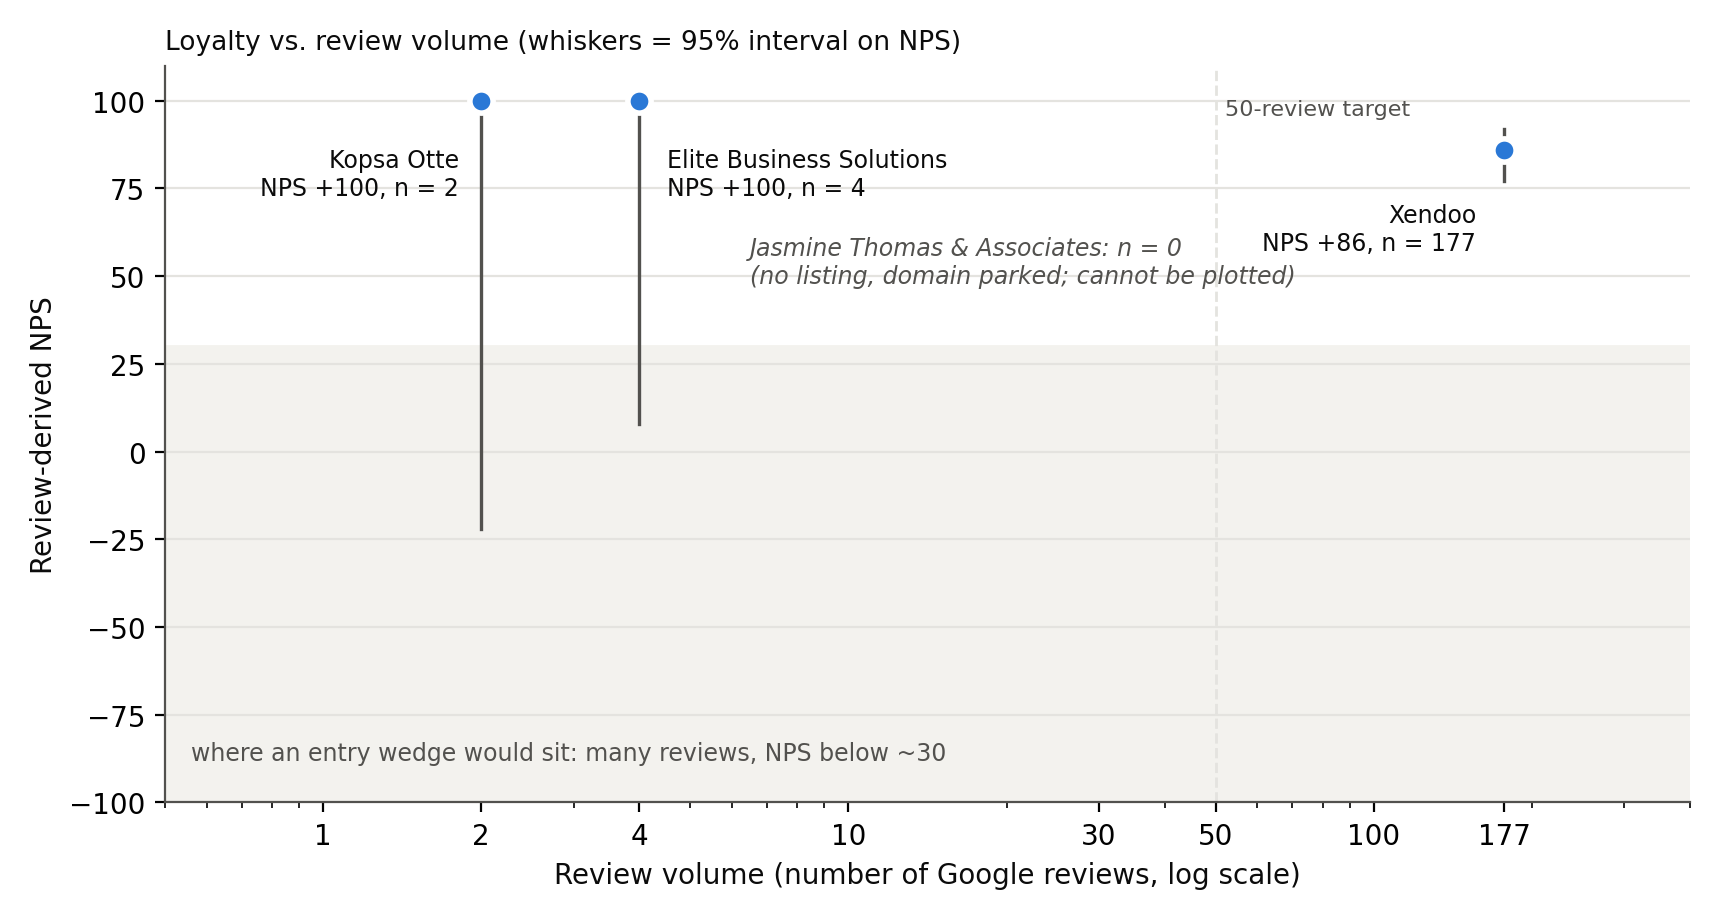

In [9]:
fig, ax = plt.subplots(figsize=(8.6, 4.6), dpi=200)
ax.axhspan(-100, 30, xmin=0, xmax=1, color="#f3f2ee", zorder=0)
ax.text(0.56, -88, "where an entry wedge would sit: many reviews, NPS below ~30",
        fontsize=8.5, color=MUTED, ha="left")
for s in ORDER:
    p = results[s]["primary"]
    if p["nps"] is None:
        continue
    lo, hi = results[s]["ci95"]
    ax.plot([p["n"], p["n"]], [lo, hi], color=MUTED, lw=1.2, zorder=2)
    ax.scatter(p["n"], p["nps"], s=70, color=BAR, edgecolor="white", linewidth=2, zorder=3)
    off = {"kopsa_otte": (-8, -34, "right"), "elite_business_solutions": (10, -34, "left"), "xendoo": (-10, -36, "right")}[s]
    short_name = {"kopsa_otte": "Kopsa Otte"}.get(s, results[s]["company"])
    ax.annotate(f"{short_name}\nNPS {p['nps']:+d}, n = {p['n']}", (p["n"], p["nps"]), ha=off[2],
                xytext=off[:2], textcoords="offset points", fontsize=8.5, color=INK)
ax.text(6.5, 48, "Jasmine Thomas & Associates: n = 0\n(no listing, domain parked; cannot be plotted)",
        fontsize=8.5, color=MUTED, style="italic")
ax.set_xscale("log"); ax.set_xlim(0.5, 400); ax.set_ylim(-100, 110)
ax.set_xticks([1, 2, 4, 10, 30, 50, 100, 177]); ax.set_xticklabels(["1", "2", "4", "10", "30", "50", "100", "177"])
ax.set_xlabel("Review volume (number of Google reviews, log scale)", color=INK)
ax.set_ylabel("Review-derived NPS", color=INK)
ax.axvline(50, color=GRID, lw=1, ls="--", zorder=1); ax.text(52, 96, "50-review target", fontsize=8, color=MUTED)
ax.grid(axis="y", color=GRID, lw=0.8, zorder=0)
for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
ax.set_title("Loyalty vs. review volume (whiskers = 95% interval on NPS)", fontsize=9.5, color=INK, loc="left")
fig.tight_layout(); fig.savefig(HERE / "nps_vs_volume.png"); plt.close(fig)
display(Image(filename=str(HERE / "nps_vs_volume.png"), width=760))

In [10]:
x = results["xendoo"]
topics = data["xendoo"].get("review_topics", [])
beauty_words = re.compile(r"\b(salon|spa|esthetic\w*|beauty|suite|stylist|lash|nail|massage|med ?spa|barber)\b", re.I)
beauty_hits = [r for r in data["xendoo"]["reviews"] if beauty_words.search(r["text"] or "")]
xero = [r for r in data["xendoo"]["reviews"] if re.search(r"\bxero\b|\bQ2X\b|migrat", r["text"] or "", re.I)]
print(f"Xendoo: {x['primary']['n']} reviews, NPS {x['primary']['nps']:+d} (95% interval {x['ci95']}); detractors {x['primary']['detractors']}.")
print("Google's review topics for Xendoo:", "; ".join(topics) if topics else "(none shown)")
print(f"Xendoo reviews whose text mentions a beauty/wellness word: {len(beauty_hits)} of {x['primary']['n']}")
for r in beauty_hits:
    print(f"   {r['stars']}* {r['date_relative']}: {r['text'][:160]!r}")
print(f"Xendoo reviews about QuickBooks-to-Xero migration (a separate product): {len(xero)} of {x['primary']['n']}")
specialists = ["kopsa_otte", "elite_business_solutions", "jasmine_thomas"]
print(f"Beauty-specialist firms: {sum(results[s]['primary']['n'] for s in specialists)} reviews combined across 3 firms; "
      f"Elite listing permanently closed; Jasmine Thomas domain parked.")
TRACK = {"xendoo_beauty_mentions": len(beauty_hits), "xendoo_xero_migration_mentions": len(xero),
         "xendoo_review_topics": topics,
         "specialist_reviews_combined": sum(results[s]["primary"]["n"] for s in specialists)}

Xendoo: 177 reviews, NPS +86 (95% interval [77, 92]); detractors 12.
Google's review topics for Xendoo: bookkeeping, mentioned in 22 reviews; tax filing, mentioned in 3 reviews; answering questions, mentioned in 30 reviews; quickbooks alternative, mentioned in 7 reviews; quick question answering, mentioned in 2 reviews; clear advice, mentioned in 4 reviews; onboarding process, mentioned in 2 reviews; pleasant staff, mentioned in 3 reviews; assigned accountant, mentioned in 3 reviews; screen sharing, mentioned in 2 reviews
Xendoo reviews whose text mentions a beauty/wellness word: 0 of 177
Xendoo reviews about QuickBooks-to-Xero migration (a separate product): 25 of 177
Beauty-specialist firms: 6 reviews combined across 3 firms; Elite listing permanently closed; Jasmine Thomas domain parked.


In [11]:
xs_ = results["xendoo"]; xp = xs_["primary"]
TRACK_TEXT = [
    ("Is there a high-volume, mediocre-NPS incumbent?",
     f"No. The only competitor with real review volume, Xendoo (n = {xp['n']}), scores NPS {xp['nps']:+d} "
     f"(95% interval {xs_['ci95'][0]:+d} to {xs_['ci95'][1]:+d}). That is high, not mediocre, and even after discounting for prompted "
     f"reviews it is not a firm whose customers are being served unremarkably. The classic wedge (many customers, lukewarm loyalty) is "
     f"not in this data."),
    ("What the data shows instead: two different empty spaces.",
     f"(1) The beauty specialists have almost no public reputation at all: {TRACK['specialist_reviews_combined']} Google reviews combined "
     f"across three firms, one listing permanently closed and one firm's domain parked. Kopsa Otte, 30+ years in salon/spa accounting, "
     f"has 2 reviews; its reputation lives in trade press and referrals, not where a new esthetician searches. "
     f"(2) The firm that does have reputation volume does not speak to this customer: {TRACK['xendoo_beauty_mentions']} of {xp['n']} "
     f"Xendoo reviews mention a salon, spa, beauty or esthetics word, while {TRACK['xendoo_xero_migration_mentions']} are about a "
     f"QuickBooks-to-Xero migration product. Its detractors describe generalist-scale failures: a tax return that was never filed, "
     f"'unknown transaction' bookkeeping, a cash-basis method that did not fit the business, and one who was turned away because the "
     f"company was not officially started yet. That last one is precisely the pre-launch esthetician."),
    ("The wedge, stated plainly.",
     "Not 'beat an unloved incumbent' but 'occupy an empty reputational position': nobody owns visible, reviewed proof of being the "
     "bookkeeper for independent estheticians and suite owners. The bar to become the most-reviewed specialist in this niche is about "
     "five reviews. The defensible entry move is to earn reviews from esthetician clients early and make them specific to the niche's "
     "pain points (1099 vs. W-2, separating personal and business spending, showing enough profit to qualify for a loan)."),
    ("Why this could be wrong.",
     "Thin review volume is ambiguous. It can mean an underserved niche, or it can mean this buyer simply does not choose a bookkeeper "
     "through Google reviews (referrals, Instagram, suite operators and beauty-school networks may matter more). Low volume is "
     "consistent with an opening but does not prove demand; interviews with estheticians about how they found their current "
     "bookkeeper would settle it. And Xendoo's high score means a well-reviewed generalist could defend the space quickly if it leaned "
     "into its Beauty & Wellness page."),
]
display(Markdown("\n\n".join(f"**{h}** {t}" for h, t in TRACK_TEXT)))

**Is there a high-volume, mediocre-NPS incumbent?** No. The only competitor with real review volume, Xendoo (n = 177), scores NPS +86 (95% interval +77 to +92). That is high, not mediocre, and even after discounting for prompted reviews it is not a firm whose customers are being served unremarkably. The classic wedge (many customers, lukewarm loyalty) is not in this data.

**What the data shows instead: two different empty spaces.** (1) The beauty specialists have almost no public reputation at all: 6 Google reviews combined across three firms, one listing permanently closed and one firm's domain parked. Kopsa Otte, 30+ years in salon/spa accounting, has 2 reviews; its reputation lives in trade press and referrals, not where a new esthetician searches. (2) The firm that does have reputation volume does not speak to this customer: 0 of 177 Xendoo reviews mention a salon, spa, beauty or esthetics word, while 25 are about a QuickBooks-to-Xero migration product. Its detractors describe generalist-scale failures: a tax return that was never filed, 'unknown transaction' bookkeeping, a cash-basis method that did not fit the business, and one who was turned away because the company was not officially started yet. That last one is precisely the pre-launch esthetician.

**The wedge, stated plainly.** Not 'beat an unloved incumbent' but 'occupy an empty reputational position': nobody owns visible, reviewed proof of being the bookkeeper for independent estheticians and suite owners. The bar to become the most-reviewed specialist in this niche is about five reviews. The defensible entry move is to earn reviews from esthetician clients early and make them specific to the niche's pain points (1099 vs. W-2, separating personal and business spending, showing enough profit to qualify for a loan).

**Why this could be wrong.** Thin review volume is ambiguous. It can mean an underserved niche, or it can mean this buyer simply does not choose a bookkeeper through Google reviews (referrals, Instagram, suite operators and beauty-school networks may matter more). Low volume is consistent with an opening but does not prove demand; interviews with estheticians about how they found their current bookkeeper would settle it. And Xendoo's high score means a well-reviewed generalist could defend the space quickly if it leaned into its Beauty & Wellness page.

## Stage 7: Write `nps_data.json` (the submission PDF is built only from this file)

In [12]:
LIMITS = [
    "Bimodal review bias: people mostly review when delighted or furious and rarely when merely satisfied, so a review-derived NPS "
    "probably overstates how polarized real customers are compared with a random-sample NPS survey (passives nearly vanish: "
    f"{four_total} four-star review out of {n_total}).",
    "Sample size: only Xendoo (177) clears the 50-review target; Kopsa Otte (2) and Elite (4) are anecdotes with 95% intervals spanning "
    "most of the scale, and Jasmine Thomas & Associates (0) cannot be scored.",
    "Star-to-NPS mapping is an approximation: a 1-5 star rating is not the 0-10 'likelihood to recommend' question NPS was designed around; "
    "the 4-star sensitivity is shown for that reason.",
    "Prompted reviews: firms can ask happy clients to review (Xendoo's owner replies to most reviews and many name a staff member), "
    "which inflates scores in a way this tool cannot measure.",
    "Scope mismatch: Xendoo's listing covers the whole firm, not only its Beauty & Wellness vertical; many reviews are about a "
    "QuickBooks-to-Xero migration product.",
    "Single source: Trustpilot was empty for all four and Yelp blocks automated access, so every score rests on Google Maps alone.",
    "Google's logged-out view varies between page loads; the collector merges reviews across runs by Google review id and checks the "
    "itemized star counts against Google's own histogram (they match exactly for every listing).",
]
out = {
    "meta": {"title": "Customer Loyalty Scorer (NPS)", "track": "Starting a company",
             "segment": "Bookkeeping, tax and loan-readiness for independent estheticians and spa/suite owners",
             "pivot_note": "Earlier deliverables (pipeline.ipynb, five_forces.ipynb) framed the project as fractional CFO services for "
                           "US SMBs (NAICS 541611); the team has since narrowed it to bookkeeping, tax and loan-readiness for independent "
                           "estheticians and spa/suite owners, so this NPS scores competitors in that narrower niche.",
             "generated": dt.datetime.now().isoformat(timespec="seconds"),
             "retrieved": sorted({data[s]["retrieved"] for s in ORDER})},
    "method": {
        "boundary": "5 stars = Promoter; 4 stars = Passive; 1-3 stars = Detractor. NPS = %Promoters - %Detractors, rounded to a whole number, on -100..+100.",
        "boundary_why": "NPS counts only 9-10 out of 10 as promoters. On Google, 5 stars is the default happy rating, so withholding the fifth star "
                        "signals a reservation: the satisfied-but-not-enthusiastic customer NPS calls passive. 1-3 stars map to detractor because on "
                        "review sites a 3-star is already a complaint, just as NPS treats 0-6 as detractor. The alternative (4 stars = promoter) is "
                        "computed for every company.",
        "source_rule": "Trustpilot first for all four (used only if >= ~15 reviews); Google Maps fallback, read in a real headless browser because the "
                       "Places API returns at most 5 reviews; Yelp checked where linked (blocked, HTTP 403). Every itemized review is cached with "
                       "source URL, stars, relative date, text and Google review id; itemized counts are checked against Google's star histogram.",
        "interval": "95% highest-density interval on NPS from a flat Dirichlet(1,1,1) prior updated with the promoter/passive/detractor counts (100,000 draws, fixed seed).",
        "who_did_what": "Reviews retrieved by collect_reviews.py (Playwright). Scores, intervals, charts and checks computed in nps_scorer.ipynb. "
                        "Prose judgments drafted by Claude Code (an LLM agent) during the build session.",
    },
    "companies": [{"slug": s, **{k: v for k, v in results[s].items()}, **sources[s]} for s in ORDER],
    "excerpts": excerpts,
    "track": {**TRACK, "text": TRACK_TEXT},
    "limits": LIMITS,
}
(HERE / "nps_data.json").write_text(json.dumps(out, indent=2, ensure_ascii=False))
print("Wrote nps_data.json")
for c in out["companies"]:
    p = c["primary"]; a = c["alt_4star_promoter"]
    f = lambda v: "n/a" if v is None else f"{v:+d}"
    print(f"  {c['company']:<30} n={p['n']:>3}  NPS {f(p['nps']):>5}  (4*=promoter: {f(a['nps'])})  source: {c['source_used'] or 'none'}")

Wrote nps_data.json
  Kopsa Otte CPAs and Advisors   n=  2  NPS  +100  (4*=promoter: +100)  source: Google Maps
  Xendoo                         n=177  NPS   +86  (4*=promoter: +86)  source: Google Maps
  Elite Business Solutions       n=  4  NPS  +100  (4*=promoter: +100)  source: Google Maps
  Jasmine Thomas & Associates    n=  0  NPS   n/a  (4*=promoter: n/a)  source: none


## Appendix A: the review collector (`collect_reviews.py`), shown in full

In [13]:
print((HERE / "collect_reviews.py").read_text())

#!/usr/bin/env python3
"""Collect public reviews for the four named competitors and cache them to nps-scorer/cache/<slug>.json.

Source priority (same for every company, so the numbers are comparable):
    1. Trustpilot  - checked for every company first. Used only if the page has >= 15 reviews.
    2. Google Maps - fallback. Loaded in a real headless browser (Playwright), because the public Places API
                     returns at most 5 "most relevant" reviews per listing. Logged out, Google Maps shows a
                     "limited view": the star histogram for EVERY review on the listing (Google's own count per
                     star level) but only ~3-6 itemized reviews; sorting, filters and "More reviews" require
                     sign-in, which this tool does not do. Both the histogram and every itemized review that
                     can be displayed are recorded.
    3. Yelp        - checked where the company itself linked a Yelp page; Yelp answers automated browser